In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d
from scipy.optimize import root
import importlib
import classy
from scipy.special import sici
from classy import Class


In [2]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'input_verbose':20,
'background_verbose':0,
'output':'mTk, vTk, mPk',
'P_k_max_1/Mpc':10,
'z_max_pk':1000,
'format':'class',
}
print(1.e-24* _ev_to_HO_)

689612003.0682429


In [7]:
# ChatGPT says that 1 eV = 4.827e19 invMpc
chiCDM = Class()
chiCDM.set(common_settings)

m_ev = 1.e-25
omega_ax = 0.1
chiCDM.set({
    'omega_cdm': 0.12 - omega_ax,
    # 'sigma8':0.793,
    'A_s': 2.149e-09,
    'scf_potential': 'axion',
    'n_axion': 1,
    'f_axion': 1.7,  # in units of mpl
    'scf_parameters': '0.5,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
    'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
    'Omega_scf' : omega_ax/h/h,
    'm_axion': m_ev * _ev_to_HO_,  # in units of H0
    'tol_shooting_deltax': 1e-4,
    'tol_shooting_deltaF': 1e-4,
    'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
    'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
    'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
    'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
    'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
    'scf_has_perturbations': 'yes',  # for pedagogical purposes only
    'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
    'use_delta_scf_over_1plusw': 'yes',
    'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
    # 'evolver': 0
})

chiCDM.compute()
#get the growth factor of a LCDM equivalent
pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({
    'N_ur': 3.046,
    'omega_cdm':0.12,
    'sigma8':0.834
})
pureCDM.compute()


Reading input parameters
Reading input parameters
Found target: Omega_scf, target value =  2.174766e-01
Computing unknown input parameter 'scf_shooting_parameter' using input parameter 'Omega_scf'
Setting phi_ini: 5.000000e-01
input file read, the h is 6.781000e-01 
input file read, the scf_shooting parameter is 5.000000e-01  with tuning index 0 (ignore if EDE)
input file read, the pba->log10_m_axion parameter is -3.000000e+01 
 -> matched budget equations by adjusting Omega_Lambda = 0.69026
Guessing in scf_parameter[0]
Setting phi_ini: 5.000000e-01
input file read, the h is 6.781000e-01 
input file read, the scf_shooting parameter is 1.801848e-01  with tuning index 0 (ignore if EDE)
input file read, the pba->log10_m_axion parameter is -3.000000e+01 
 -> matched budget equations by adjusting Omega_Lambda = 0.69026
Stage 1: background
Where does the code end up? 
rho_ax / rho_crit: 3.796393e-01
distance away from target: 1.621627e-01
Setting phi_ini: 5.000000e-01
input file read, the h 

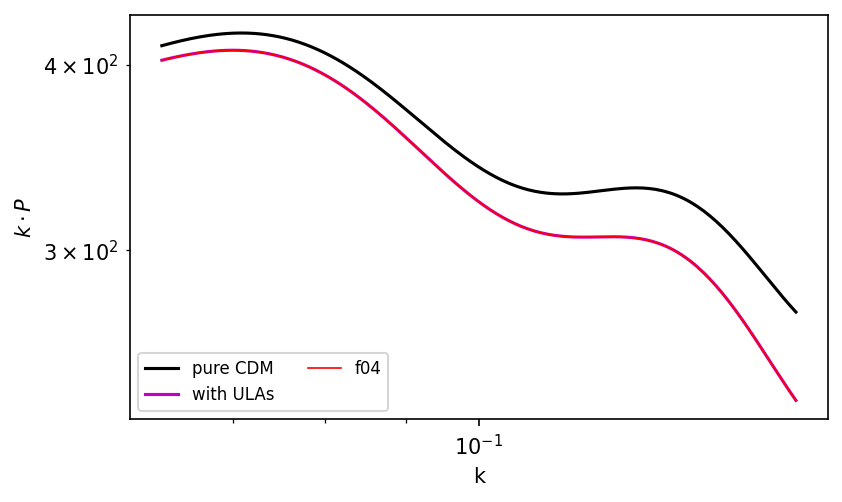

2.3010299956639813 -0.3010299956639812


In [35]:
kk = np.logspace(-1.2,-0.8,200); h = chiCDM.h(); Pk_list=[]
for k in kk:
    Pk_list.append([chiCDM.pk_lin(k*h,0.5)*h**3,pureCDM.pk_lin(k*h,0.5)*h**3]) # function .pk(k,z)
Pk_list=np.array(Pk_list).T

plt.figure(figsize=(6.,3.5), dpi=150)
plt.plot(kk, kk*Pk_list[1], 'k', label=f'pure CDM')
plt.plot(kk, kk*Pk_list[0],'m', label=f'with ULAs')
# Pk_list_f04 = Pk_list[0]

plt.plot(kk, kk*Pk_list_f04,'r', linewidth=0.8,label=f'f04')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel(r'$k\cdot P$')
plt.legend(loc='lower left', fontsize=8, ncol=2)

# plt.ylim([1.,None])

plt.show()
print(np.log10(200),np.log10(0.5))

Reading input parameters
Reading input parameters
Found target: Omega_scf, target value =  2.174766e-01
Computing unknown input parameter 'scf_shooting_parameter' using input parameter 'Omega_scf'
Setting phi_ini: 5.000000e-01
input file read, the h is 6.781000e-01 
input file read, the scf_shooting parameter is 5.000000e-01  with tuning index 0 (ignore if EDE)
input file read, the pba->log10_m_axion parameter is -3.000000e+01 
 -> matched budget equations by adjusting Omega_Lambda = 0.69026
Guessing in scf_parameter[0]
Setting phi_ini: 5.000000e-01
input file read, the h is 6.781000e-01 
input file read, the scf_shooting parameter is 1.801848e-01  with tuning index 0 (ignore if EDE)
input file read, the pba->log10_m_axion parameter is -3.000000e+01 
 -> matched budget equations by adjusting Omega_Lambda = 0.69026
Stage 1: background
Where does the code end up? 
rho_ax / rho_crit: 1.271923e-03
distance away from target: -2.162047e-01
Setting phi_ini: 5.000000e-01
input file read, the h

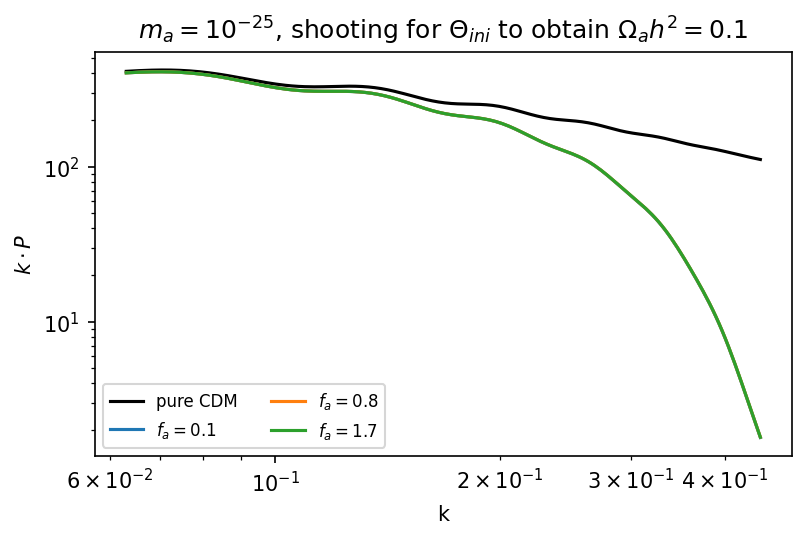

In [12]:
kk = np.logspace(-1.2,-0.35,200); h = chiCDM.h(); Pk_list=[]

plt.figure(figsize=(6.,3.5), dpi=150)
Pkax = np.array([pureCDM.pk_lin(k*h,0.5)*h**3 for k in kk])
plt.plot(kk, kk*Pkax, 'k', label=f'pure CDM')

chiCDM.set({'f_axion':0.1})
chiCDM.compute()
Pkax = np.array([chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk])
plt.plot(kk, kk*Pkax,label=f'$f_a=0.1$')

chiCDM.set({'f_axion':0.8})
chiCDM.compute()
Pkax = np.array([chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk])
plt.plot(kk, kk*Pkax,label=f'$f_a=0.8$')


chiCDM.set({'f_axion':1.7})
chiCDM.compute()
Pkax = np.array([chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk])
plt.plot(kk, kk*Pkax,label=f'$f_a=1.7$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel(r'$k\cdot P$')
plt.legend(loc='lower left', fontsize=8, ncol=2)

# plt.ylim([1.,None])
plt.title('$m_a=10^{-25}$, shooting for $\Theta_{ini}$ to obtain $\Omega_a h^2=0.1$')
plt.show()


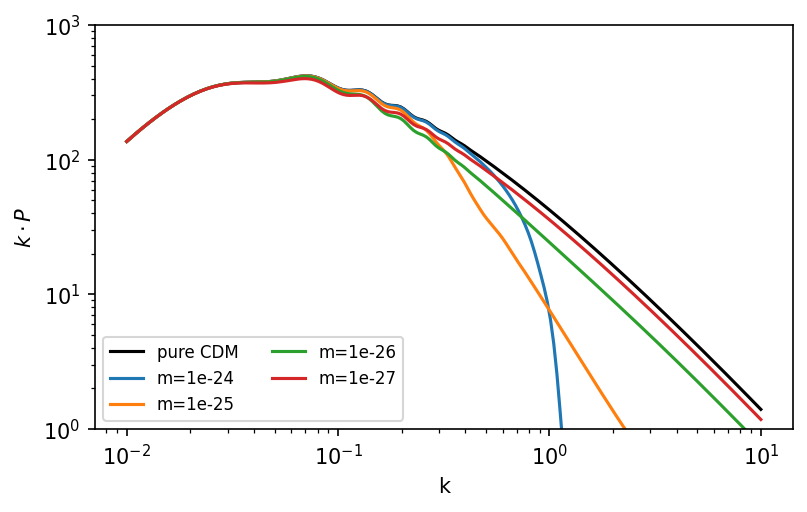

In [5]:
mlist = [[1.e-24, 0.1],[1.e-25, 0.033],[1.e-26,0.007],[1.e-27,0.002]]

plt.figure(figsize=(6.,3.5), dpi=150)
kk = np.logspace(-2.,1.,200); h = chiCDM.h(); 

Pk_list = [pureCDM.pk_lin(k*h,0.5)*h**3 for k in kk] 
plt.plot(kk, kk*Pk_list, 'k', label=f'pure CDM')

for mcopule in mlist:
    mev , oax = mcopule
    chiCDM.set({
    'omega_cdm': 0.12 - oax,
    'Omega_scf' : oax/h/h,
    'm_axion': mev * _ev_to_HO_,  # in units of H0
    })
    chiCDM.compute()
    Pk_list = [chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk]  

    plt.plot(kk, kk*Pk_list, label=f'm={mev}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel(r'$k\cdot P$')
plt.legend(loc='lower left', fontsize=8, ncol=2)

plt.ylim([1.,None])
# plt.xlim([None, 0.2])
plt.show()

---
CMB

In [4]:
newcommon = {'lensing' : 'yes', 'output':'mPk tCl pCl lCl','temperature_contributions':'tsw, eisw, lisw, dop, pol'}

pureCDM.set(newcommon);chiCDM.set(newcommon)
# pureCDM.set({'temperature_contributions':'tsw, eisw, lisw, dop, pol'})
pureCDM.compute()
l = pureCDM.raw_cl()['ell'][2:]
chiCDM.compute()

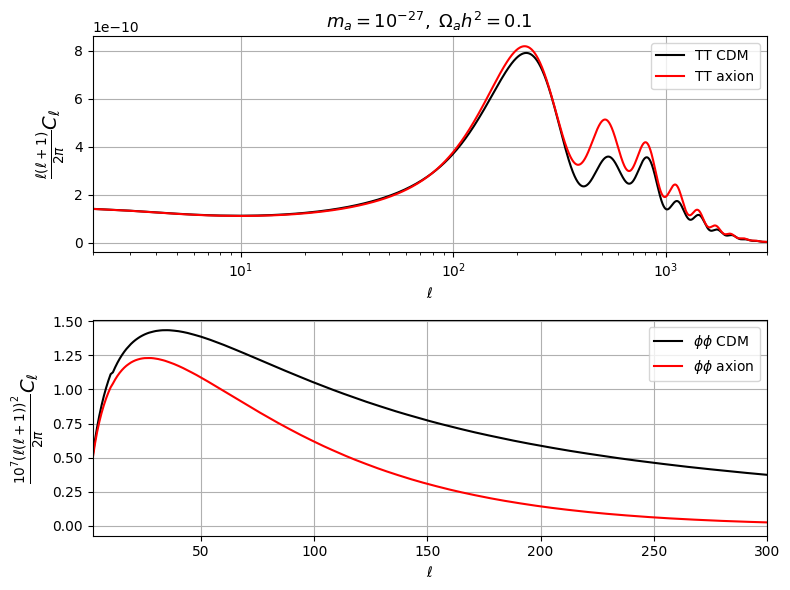

In [7]:
plt.figure(figsize=(8, 6))

# First plot
plt.subplot(2, 1, 1)
plt.semilogx(l, l * (l + 1) * pureCDM.raw_cl()['tt'][2:] / (2 * np.pi), 'k', label='TT CDM')
plt.semilogx(l, l * (l + 1) * chiCDM.raw_cl()['tt'][2:] / (2 * np.pi), 'r', label='TT axion')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell+1)}{2\pi}C_\ell$', fontsize=14)
plt.legend()
plt.grid(True)
plt.xlim([2,3.e3])
plt.title(r'$m_a=10^{-27},\; \Omega_a h^2 =0.1$', fontsize=13)
# Second plot
plt.subplot(2, 1, 2)
plt.plot(l, 1.e7 * pow(l * (l + 1), 2) * pureCDM.raw_cl()['pp'][2:] / (2 * np.pi), 'k', label=r'$\phi\phi$ CDM')
plt.plot(l, 1.e7 * pow(l * (l + 1), 2) * chiCDM.raw_cl()['pp'][2:] / (2 * np.pi), 'r', label=r'$\phi\phi$ axion')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{10^{7}(\ell(\ell+1))^2}{2\pi}C_\ell$', fontsize=14)
plt.legend()
plt.grid(True)
plt.xlim([2, 300])

plt.tight_layout()
plt.show()